# Case study 2: PNW heat dome with `its2s`

ITS counterfactual on Washington weekly injury deaths (`case_study2_data_clean.ipynb`), using **Prophet + XGBoost** (`prophet_xgb`). No covariates.

- **Data:** `../data/pnw_heatwave_injury_deaths_weekly.csv` (weekly, 2014–2021)
- **Intervention:** 2021-06-25
- **Holdout:** 3 weeks post-intervention (through week starting **2021-07-10**)
- **Split:** custom `days` windows (`split_method="days"`) because the default percent split is intended for daily series


In [5]:
# load packages 
from pathlib import Path
import logging
import warnings
import pandas as pd
from IPython.display import Image, display
from its2s import run_single_its

# ignore warnings to clean up output
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)
for _name in ("cmdstanpy", "prophet", "stan", "its2s", "xgboost", "matplotlib"):
    logging.getLogger(_name).setLevel(logging.WARNING)

# setup
DATA_PATH = Path("../data/pnw_heatwave_injury_deaths_weekly.csv")
OUT_DIR = Path("../outputs")
INTERVENTION = "2021-06-25"
HOLDOUT_LAST_WEEK = pd.Timestamp("2021-07-10")

df = pd.read_csv(DATA_PATH, parse_dates=["ds"]).sort_values("ds").reset_index(drop=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

_intv = pd.Timestamp(INTERVENTION)
_holdout_days = (HOLDOUT_LAST_WEEK - _intv).days
_test_days = max(28, int(0.20 * (df["ds"] < _intv).sum()))

In [8]:
# run its2s

result = run_single_its(
    df,
    intervention_date=INTERVENTION,
    config_overrides={
        "periods": {
            "split_method": "days",
            "test_days": _test_days,
            "holdout_days": _holdout_days,
        },
    },
    output_dir=OUT_DIR,
)

print(result.summary())

Model: prophet_xgb
Bootstrap: 1000 simulations, 1000 successful

Train metrics:
  RMSE=7.6122  MAE=6.0352  MAPE=6.31%  R2=0.7295
Test metrics:
  RMSE=10.5724  MAE=7.3061  MAPE=5.53%  R2=0.1858

Total ATE: 192.92 [179.27, 217.48]
Mean Daily ATE: 64.3082 [59.7577, 72.4918]
Holdout days: 3

Residual diagnostics:
  Mean=0.0800  Std=7.6219
  ACF(1)=0.087  ACF(7)=-0.030  ACF(14)=0.014
  Ljung-Box(10) p=0.0062
  Shapiro-Wilk p=0.4282


## Excess during 3-week holdout


In [11]:
# results 

row = result.excess_table.period_excess.iloc[0]
# period CIs are on total excess (counts); convert to % for display
pct_lo = 100 * row["excess_ci_lo"] / row["total_expected"]
pct_hi = 100 * row["excess_ci_hi"] / row["total_expected"]

display(result.excess_table.daily_excess.round(1))

print(
    f"Total excess: {row['total_excess']:.0f} "
    f"[{row['excess_ci_lo']:.0f}, {row['excess_ci_hi']:.0f}]  |  "
    f"Percent excess vs expected: {row['excess_pct']:+.1f}% "
    f"[{pct_lo:+.1f}%, {pct_hi:+.1f}%]"
)

,date,observed,expected,expected_ci_lo,expected_ci_hi,excess,excess_ci_lo,excess_ci_hi,excess_pct,excess_pct_ci_lo,excess_pct_ci_hi
0,2021-06-26,150.0,116.2,105.1,122.1,33.8,27.9,44.9,29.1,24.0,38.6
1,2021-07-03,229.0,124.8,111.4,129.9,104.2,99.1,117.6,83.5,79.4,94.2
2,2021-07-10,178.0,123.1,113.6,131.9,54.9,46.1,64.4,44.6,37.4,52.3


Total excess: 193 [179, 217]  |  Percent excess vs expected: +53.0% [+49.2%, +59.7%]


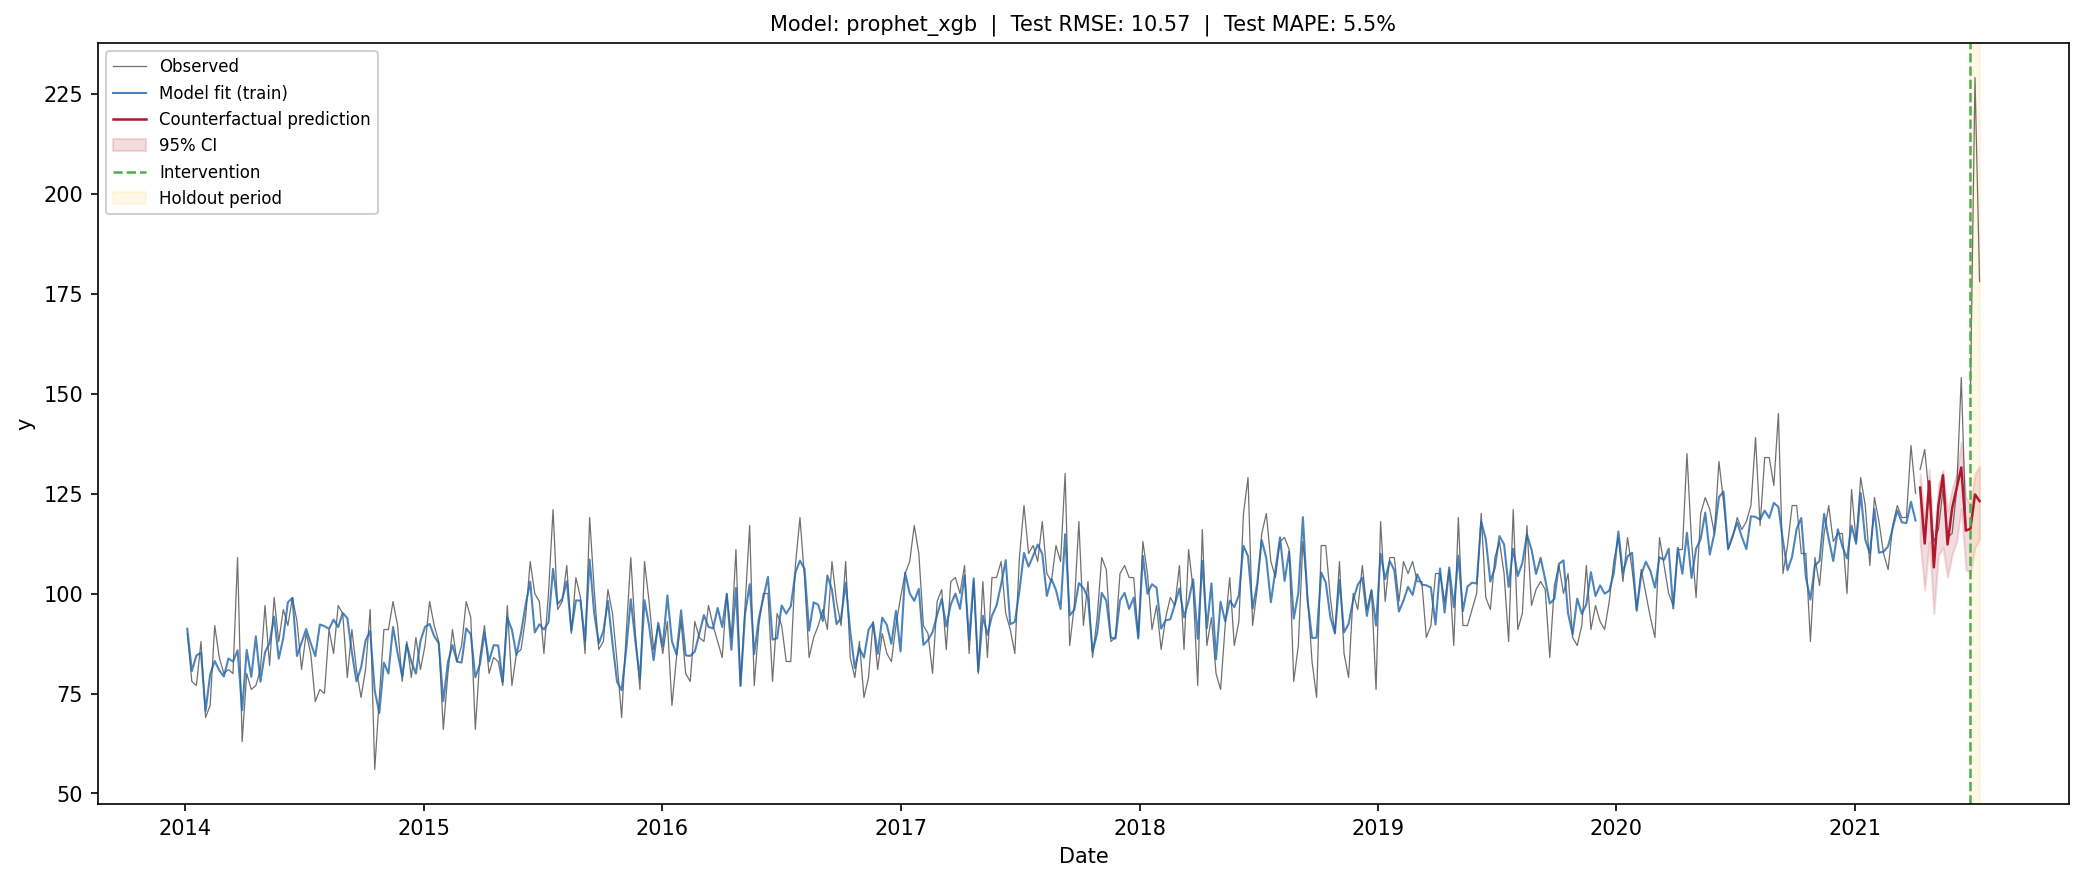

In [10]:
display(Image(filename=OUT_DIR / f"{result.model_name}_counterfactual.png"))